# Explanation for Specific instance
This notebook will see how the LIME and SHAP plots changes for a single instance

In [1]:
import argparse
import logging
import pathlib

import masking_effects_on_xai_techniques.anjana_utils as utils
import masking_effects_on_xai_techniques.anonymized_preprocessor as anon_prep
from masking_effects_on_xai_techniques.datasets import Dataset

import os
import numpy as np
import pandas as pd
import shap
import sklearn
from lime import submodular_pick  # pyright: ignore[reportMissingModuleSource]
from lime import lime_tabular  # pyright: ignore[reportMissingModuleSource]
from pandas import DataFrame
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler

shap.initjs()

def standardize_sensitive_attr(y_train, y_test):
    scaler = StandardScaler()
    _ = scaler.fit(y_train.values.reshape(-1, 1))
    y_train = scaler.transform(y_train.values.reshape(-1, 1))
    y_test = scaler.transform(y_test.values.reshape(-1, 1))
    return y_train, y_test


def _create_classifier(
    classifier_type: str,
) -> MLPClassifier | KNeighborsClassifier | RandomForestClassifier:
    if classifier_type == "MLP":
        return MLPClassifier(max_iter=2000)
    elif classifier_type == "forest":
        return RandomForestClassifier()
    elif classifier_type == "knn":
        return KNeighborsClassifier()
    else:
        raise ValueError(f"{classifier_type} is not a valid model")


def _clean_feature_names(features):
    names = []
    for key in features:
        if 1 == (key.count("<") + key.count(">")):
            key = key.split(" ")[0]
        elif 2 <= key.count("<"):
            key = key.split(" ")[2]
        else:
            key = key.split("=")[0]
        names.append(key)
    return names


def _name_weights(relation, features):
    names = _clean_feature_names(features)
    return [(names[i], weight) for i, weight in relation]


def _importance_vector_of(exp):
    relations = exp.as_map()[1]
    features = exp.domain_mapper.feature_names
    relations = _name_weights(relations, features)
    return [(_, np.abs(w)) for _, w in relations]


def importance_vector_sum(submoduler_exp) -> list[tuple[str, float]]:
    sp_exp = [exp for exp in submoduler_exp.sp_explanations]

    importance_vectors = [_importance_vector_of(exp) for exp in sp_exp]

    feature_sums = {}
    for explanation in importance_vectors:
        for feature_name, importance_score in explanation:
            feature_sums[feature_name] = (
                feature_sums.get(feature_name, 0.0) + importance_score
            )

    summed_list_sorted = sorted(
        list(feature_sums.items()),
        key=lambda item: item[1],  # pyright: ignore[reportUnknownLambdaType]
        reverse=True,
    )
    return summed_list_sorted


def normalize_feature(train: DataFrame, feature: str) -> StandardScaler:
    scaler = StandardScaler()
    _ = scaler.fit(train[[feature]])
    return scaler


def one_hot_encoding(df: DataFrame, feature: str, encoder) -> DataFrame:
    encoded_array = encoder.transform(df[[feature]])

    feature_names = encoder.get_feature_names_out([feature])
    df_encoded_part = pd.DataFrame(encoded_array, columns=feature_names, index=df.index)
    return df.drop([feature], axis=1).join(df_encoded_part)


def importance_values_to_str(features: list[str], importance) -> list[tuple[str, int]]:
    return [(features[i], importance[i]) for i in np.argsort(-importance)]


def create_one_hot_encoder(df: pd.DataFrame, feature: str) -> OneHotEncoder:
    return OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(
        df[[feature]]
    )


def create_hierachy(quasi_identifiers: list[str], hierarchy_path: str):
    hierarachies = {}
    for feat in quasi_identifiers:
        hierarachy = dict(pd.read_csv(f"{hierarchy_path}{feat}.csv", header=None))
        hierarachies[feat] = hierarachy

    return hierarachies


In [64]:
def find_shap(df, dataset):
    
    logging.info("Calculating SHAP importance values.")
    numeric_features = dataset.numeric_features
    skip_columns = []
    logging.info("Identifying numeric features to skip from encoding.")
    for feature in numeric_features:
        # if feature is numeric in df then add to skip_columns
        d_type = type(df[feature].iloc[0])
        if d_type is not str:
            skip_columns.append(feature)
    logging.info(f"Skipping encoding for numeric features: {skip_columns}")
    
    df = anon_prep.encode(df, hierarchy_path=dataset.hierarchy_path, skip=skip_columns)
    
    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(  # pyright: ignore[reportAttributeAccessIssue]
        df.drop([dataset.sensitive_attr], axis=1),
        df[dataset.sensitive_attr],
        test_size=0.4,
        random_state=0,
    )
    
    numeric_encoders = {}
    
    for feature in numeric_features:
        if feature not in skip_columns:
            continue
        logging.info(f"Normalizing feature '{feature}'")
        numeric_encoders[feature] = normalize_feature(X_train, feature)
        X_train[feature] = numeric_encoders[feature].transform(X_train[[feature]])
        X_test[feature] = numeric_encoders[feature].transform(X_test[[feature]])
    
    logging.info(
        f"Data split into training and testing sets. Training set size: {len(X_train)}, Testing set size: {len(X_test)}"
    )
    
    clf = _create_classifier(dataset.classifier_type)
    logging.info("Training Model.")
    
    _ = clf.fit(np.array(X_train), y_train)
    print(f"Classifier classes: {clf.classes_}")
    # Verify what index 1 represents
    if len(clf.classes_) > 1:
        print(f"Explaining probability of Class: {clf.classes_[1]}")
    else:
        print("Classifier only has one class!")
    score = clf.score(np.array(X_test), y_test)
    logging.info(f"Model training finished. Score: {score}")
    
    def f(x):  # pyright: ignore[reportRedeclaration]
        return clf.predict_proba(x)[:, 1]  # pyright: ignore[reportAttributeAccessIssue]

    med = X_train.median().values.reshape((1, X_train.shape[1]))
    explainer = shap.KernelExplainer(f, med)
    
    logging.info("Calculating SHAP values.")
    shap_values = explainer(X_test)
    
    importance = np.mean(np.abs(shap_values.values), axis=0)
    logging.info("SHAP importance calculation finished.")
    return shap_values

We investigate usa_house alpha_k_anonymity 0.8 (0.53, 33%) and 0.5 (0.37, 73%)

In [65]:
df = pd.read_csv("../data/usa_house/alpha_k_anonymity/0.8.csv")
df2 = pd.read_csv("../data/usa_house/alpha_k_anonymity/0.5.csv")
dfo = df.copy()

Below confirms that the dataset is encoded the right way. The vast majority of instances corresponding to low price has low values, *not* high ones. High values are more related to high prices

In [66]:
df[df['Price']==1].value_counts(normalize=True)

Avg. Area Income         Avg. Area House Age          Avg. Area Number of Rooms    Avg. Area Number of Bedrooms  Area Population                  Price
(17796.63, 68785.855]    (2.6430000000000002, 5.544]  (3.2350000000000003, 6.568]  (1.999, 3.27]                 (31797.131, 40447.994]           1        0.054775
                                                                                   (3.27, 4.35]                  (31797.131, 40447.994]           1        0.053371
                                                                                   (1.999, 3.27]                 (172.60999999999999, 31797.131]  1        0.043539
                                                      (7.425, 10.28]               (4.35, 6.5]                   (172.60999999999999, 31797.131]  1        0.043539
                         (5.544, 6.407]               (3.2350000000000003, 6.568]  (1.999, 3.27]                 (172.60999999999999, 31797.131]  1        0.037921
                            

In [67]:
qi = list(df.columns)
sensitive_attr = "Price"
qi.remove(sensitive_attr)
numeric_features = list(df.columns)
numeric_features.remove(sensitive_attr)
dataset = Dataset(
    "usa_house",
    numeric_features,
    "../hierarchies/usa_house/",
    sensitive_attr,
    "MLP",
    qi,
)

In [68]:
shap_values=find_shap(df, dataset)
shap_values2=find_shap(df2, dataset)

Classifier classes: [0. 1. 2. 3. 4. 5.]
Explaining probability of Class: 1.0


  0%|          | 0/1894 [00:00<?, ?it/s]

Classifier classes: [0. 1. 2. 3. 4. 5.]
Explaining probability of Class: 1.0


  0%|          | 0/1835 [00:00<?, ?it/s]

In [69]:
df['Price'].value_counts(normalize=True)

Price
3.0    0.317769
2.0    0.315233
1.0    0.150433
4.0    0.148743
0.0    0.034650
5.0    0.033171
Name: proportion, dtype: float64

So why the fuck are low high values contributing to a negative effect? Because, we are considering class [1], i.e. houses part of the second lowest price class. High values decrease the probability of having an expensive house. Makes sence. But low values actually increase the probaility!  
We see two big differences on these plots. We lose granularity. All feature values are either high or low at alpha-k-anonymity 0.5. And only high values contribute to a lower probability.  
Also note, the fact that we have fixed our ranking to one target class does not ruin everything. SHAP cannot visualize it if you calculate SHAP values for each target class. The rankings you would get would be the rankings across all target classes. Then you would sum all the absolute SHAP values across all features to find which features are the most important ones. This is slightly different from what I have done. But that is okey. I just want to see how it is affected by annonymization. Now I have characterized how it changes if you only consider one variable

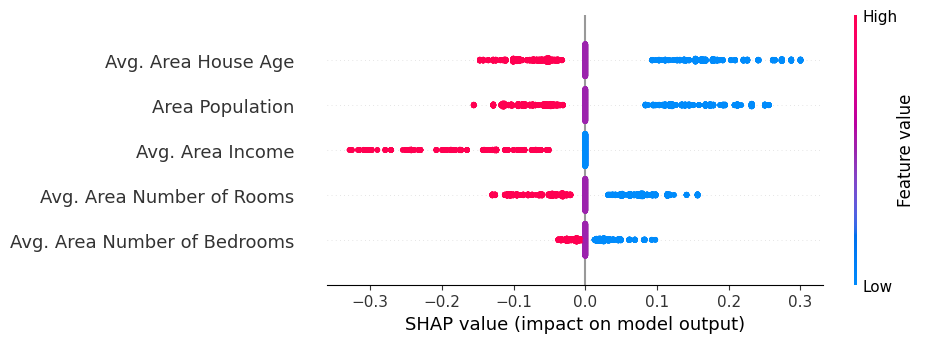

In [70]:
shap.plots.beeswarm(shap_values)

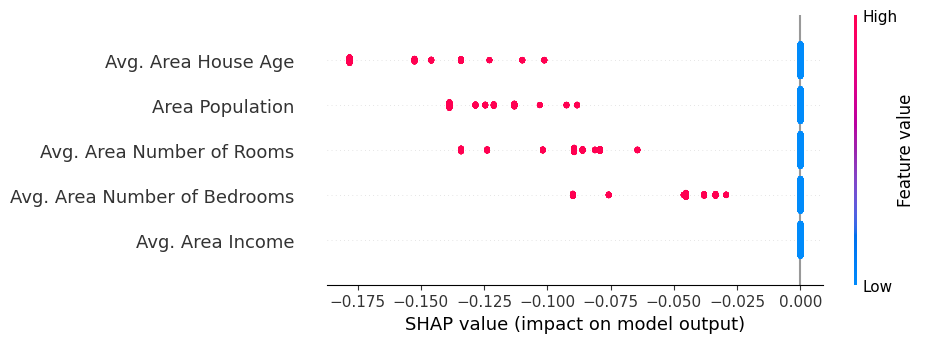

In [71]:
shap.plots.beeswarm(shap_values2)

# Cervic Cancer

In [3]:
df = pd.read_csv("../data/cervic_cancer/k_anonymity/2.csv")
df2 = pd.read_csv("../data/cervic_cancer/k_anonymity/16.csv")

In [7]:
df2['disease'].value_counts()

disease
6    236
1    223
4    211
5    199
3    182
0    157
2    127
Name: count, dtype: int64

In [4]:
qi = list(df.columns)
sensitive_attr = "disease"
qi.remove(sensitive_attr)
num_i = [0, 5, 6, 8]
numeric_features = [df.columns[i] for i in num_i]
dataset = Dataset(
    "cervic_cancer",
    numeric_features,
    "../hierarchies/cervic_cancer/",
    sensitive_attr,
    "MLP",
    qi,
)


In [5]:
shap_values=find_shap(df, dataset)
shap_values2=find_shap(df2, dataset)

  0%|          | 0/504 [00:00<?, ?it/s]

  0%|          | 0/534 [00:00<?, ?it/s]

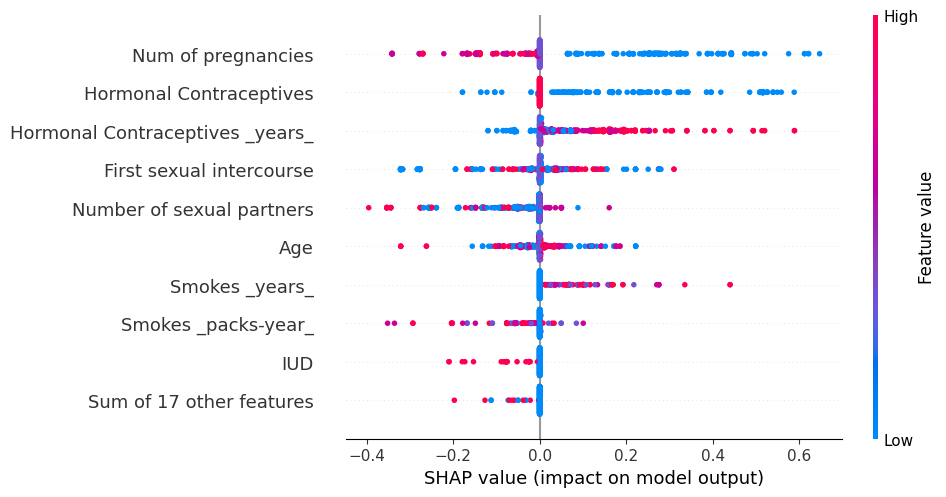

In [7]:
shap.plots.beeswarm(shap_values)

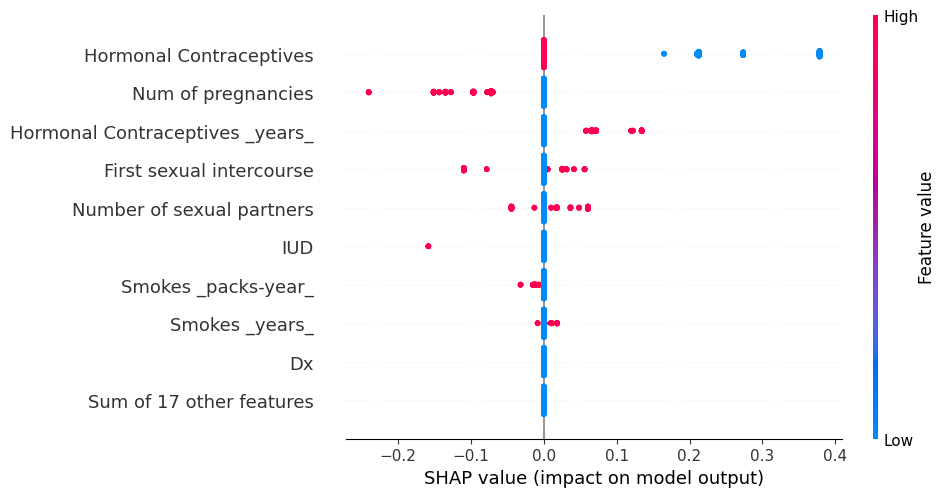

In [8]:
shap.plots.beeswarm(shap_values2)